In [2]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [3]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [4]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


In [5]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [11]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [12]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

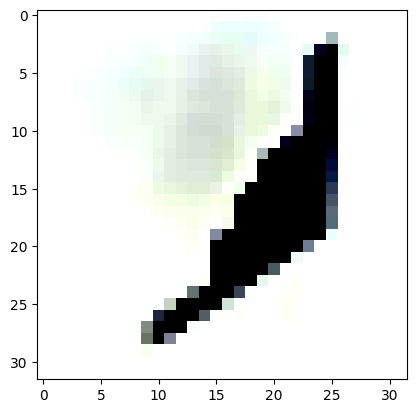

In [13]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [14]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [15]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [16]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [58]:
class Trainer:
    def __init__(self, config, transform=None, model=None):
        if model is None:
            model = BasicCNN()
        self.config = config
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.model = model.to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.setup_dataloaders()

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(list(range(len(train_dataset_full))), test_size=self.config['test_size'], random_state=42, shuffle=True)
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def run(self):

      train_losses = []
      val_losses = []
      train_accs = []
      val_accs = []
      test_accs = []

      for epoch in range(self.config['num_epochs']):

          train_loss, train_acc = self.train_step()
          val_loss, val_acc = self.val_step()
          test_loss, test_acc = self.test_step()

          train_losses.append(train_loss)
          val_losses.append(val_loss)

          train_accs.append(train_acc)
          val_accs.append(val_acc)

          test_accs.append(test_acc)

          print(f"Epoch {epoch+1}/{self.config['num_epochs']}  train_acc={train_acc:.2f}  val_acc={val_acc:.2f}  test_acc={test_acc:.2f}")

      history = {
          "train_loss": train_losses,
          "val_loss": val_losses,
          "train_acc": train_accs,
          "val_acc": val_accs,
          "test_acc": test_accs
      }

      return history

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.val_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100

        return total_loss, val_acc

    def test_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.test_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.test_loader)
        test_acc = correct / total_samples * 100

        return total_loss, test_acc

In [21]:
trainer = Trainer(config, transform=transform)

In [22]:
trainer.run()

100%|██████████| 79/79 [00:02<00:00, 29.68it/s]


Epoch 1 / 10 2.3069628518991196 2.303790038145041 9.33


100%|██████████| 79/79 [00:03<00:00, 23.01it/s]


Epoch 2 / 10 2.30333688083929 2.303951876072944 9.33


100%|██████████| 79/79 [00:02<00:00, 29.07it/s]


...

Epoch 8 / 10 2.302662766398713 2.302944657168811 9.33


100%|██████████| 79/79 [00:02<00:00, 29.56it/s]


Epoch 9 / 10 2.302664668415301 2.3029022035719473 9.33


100%|██████████| 79/79 [00:02<00:00, 29.66it/s]

Epoch 10 / 10 2.302660680045716 2.3028568798982643 9.33


# ResNet-18

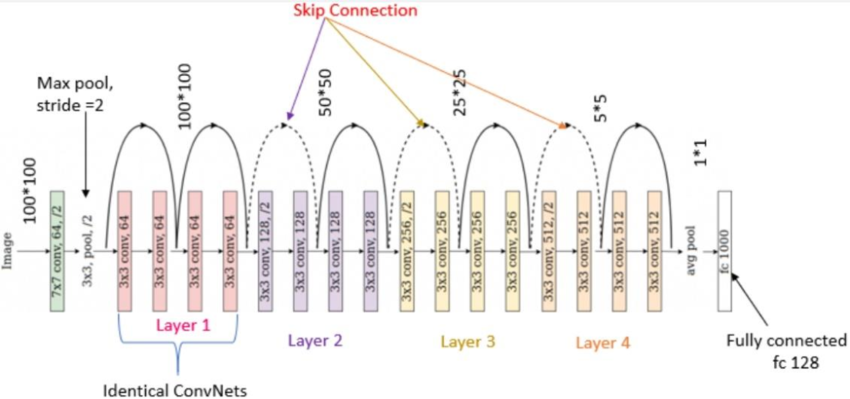

In [23]:
class ResNetBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.downsample = downsample

    def forward(self, x):

        identity = x

        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out

class ResNet18(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self.make_layer(64, 2)
        self.layer2 = self.make_layer(128, 2, stride=2)
        self.layer3 = self.make_layer(256, 2, stride=2)
        self.layer4 = self.make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):

        downsample = None

        if stride != 1 or self.in_channels != out_channels:

            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []

        layers.append(
            ResNetBlock(self.in_channels, out_channels, stride, downsample)
        )

        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(ResNetBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

In [28]:
device = torch.device("cuda" )
print(device)

cuda


In [43]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [59]:
cnn_model = BasicCNN().to(device)

trainer_cnn = Trainer(
    config=config,
    transform=transform,
    model=cnn_model
)
cnn_history = trainer_cnn.run()

100%|██████████| 79/79 [00:03<00:00, 20.93it/s]


Epoch 1/10  train_acc=37.15  val_acc=46.56  test_acc=46.16


100%|██████████| 79/79 [00:02<00:00, 29.88it/s]


Epoch 2/10  train_acc=48.41  val_acc=50.06  test_acc=49.37


100%|██████████| 79/79 [00:02<00:00, 30.95it/s]


...

Epoch 8/10  train_acc=63.87  val_acc=59.93  test_acc=58.71


100%|██████████| 79/79 [00:02<00:00, 30.19it/s]


Epoch 9/10  train_acc=64.46  val_acc=59.72  test_acc=59.25


100%|██████████| 79/79 [00:02<00:00, 30.73it/s]

Epoch 10/10  train_acc=64.94  val_acc=60.16  test_acc=59.68


In [60]:
resnet_model = ResNet18().to(device)

trainer_resnet = Trainer(
    config=config,
    transform=transform,
    model=resnet_model
)
resnet_history = trainer_resnet.run()

100%|██████████| 79/79 [00:03<00:00, 22.16it/s]


Epoch 1/10  train_acc=34.38  val_acc=42.47  test_acc=43.27


100%|██████████| 79/79 [00:04<00:00, 19.57it/s]


Epoch 2/10  train_acc=48.91  val_acc=52.96  test_acc=53.50


100%|██████████| 79/79 [00:03<00:00, 22.21it/s]


...

Epoch 8/10  train_acc=85.39  val_acc=74.24  test_acc=73.66


100%|██████████| 79/79 [00:03<00:00, 22.39it/s]


Epoch 9/10  train_acc=87.98  val_acc=74.42  test_acc=73.75


100%|██████████| 79/79 [00:04<00:00, 19.74it/s]

Epoch 10/10  train_acc=90.84  val_acc=73.70  test_acc=73.58


In [61]:
print(resnet_history)

{'train_loss': [1.8396324402988908, 1.4083065282041654, 1.1562170070200302, 0.9856475924912352, 0.8429361438979737, 0.5763375954315685, 0.48291647700836865, 0.4175183450261625, 0.34546847822376714, 0.2682152972482264], 'val_loss': [1.5732789250868786, 1.3222119204605682, 1.2606013198442096, 0.9863579031787341, 0.889514809922327, 0.7631640185283709, 0.7846601507331752, 0.7949495594712752, 0.8534129978735235, 0.944932633562933], 'train_acc': [34.3825, 48.915, 58.940000000000005, 65.21000000000001, 70.3025, 79.77250000000001, 83.015, 85.3925, 87.985, 90.845], 'val_acc': [42.47, 52.959999999999994, 56.589999999999996, 64.95, 68.67999999999999, 73.98, 74.33999999999999, 74.24, 74.42, 73.7], 'test_acc': [43.269999999999996, 53.5, 57.489999999999995, 65.5, 68.84, 73.54, 73.48, 73.66, 73.75, 73.58]}


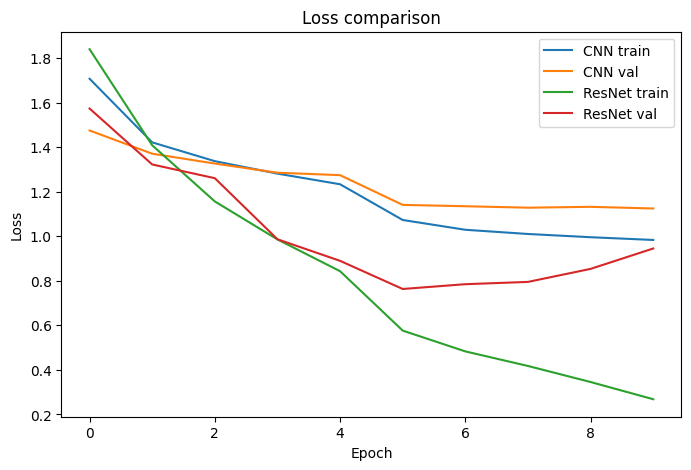

In [62]:
plt.figure(figsize=(8,5))

plt.plot(cnn_history["train_loss"], label="CNN train")
plt.plot(cnn_history["val_loss"], label="CNN val")

plt.plot(resnet_history["train_loss"], label="ResNet train")
plt.plot(resnet_history["val_loss"], label="ResNet val")

plt.title("Loss comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

Красная линия — (validation loss)
после 6 эпох немного растет ->

признак: небольшого переобучения (overfitting).

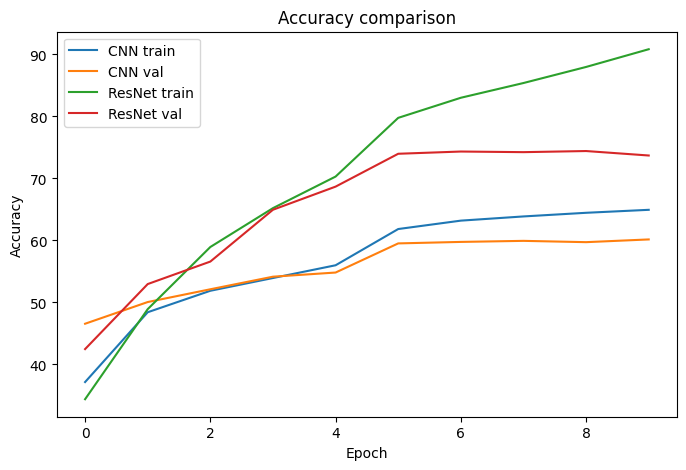

In [63]:
plt.figure(figsize=(8,5))

plt.plot(cnn_history["train_acc"], label="CNN train")
plt.plot(cnn_history["val_acc"], label="CNN val")

plt.plot(resnet_history["train_acc"], label="ResNet train")
plt.plot(resnet_history["val_acc"], label="ResNet val")

plt.title("Accuracy comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

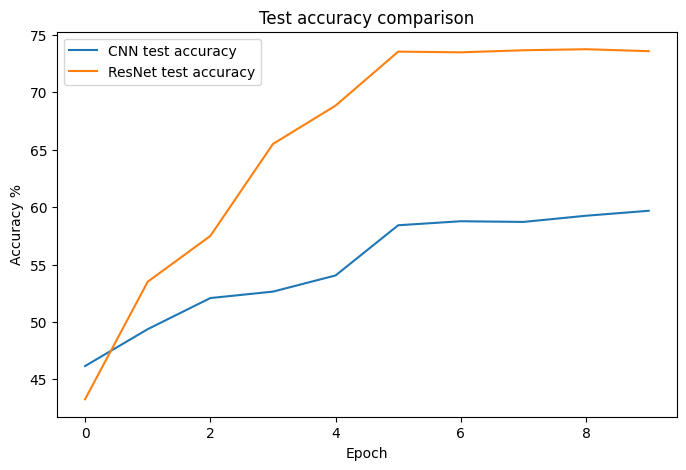

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(cnn_history["test_acc"], label="CNN test accuracy")
plt.plot(resnet_history["test_acc"], label="ResNet test accuracy")

plt.title("Test accuracy comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy %")

plt.legend()
plt.show()

В остальном видно что RESNET обучается быстрее, достигает меньшей ошибки,а CNN достигает плато раньше и демонстрирует более высокую ошибку